# What the model uses

Two views of the same question. Occlusion measures what the model loses when a band disappears.
Grad-CAM shows where the last convolutional stage responded. The first is a cost the model pays,
the second is a lead worth following, and they belong together.

Run `python -m src.evaluate.explain --config configs/base.yaml --model-config configs/cnn_small.yaml
--name cnn_small --fold 3` first.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd().parent))
from src.config import load_config

cfg = load_config("configs/base.yaml")
META = cfg.paths.metadata
REPORT = cfg.paths.reports / cfg.name
pd.set_option("display.width", 160)

# The CNN capacity that won on validation is the one that was explained.
EXPLAINED = next(
    d.name for d in sorted(REPORT.iterdir()) if d.is_dir() and (d / "occlusion.csv").exists()
)
print("explaining variant:", EXPLAINED)

explaining variant: cnn_small


## Frequency band occlusion

Each row masks one contiguous group of mel bands on held-out tapes and rescores. A band the model
genuinely relies on shows a positive drop. Read the per-species columns against the call bands each
animal is known to use.

In [2]:
occlusion = pd.read_csv(REPORT / EXPLAINED / "occlusion.csv")
columns = ["band_low_hz", "band_high_hz", "macro_f1", "macro_f1_drop"]
columns += [c for c in occlusion.columns if c.startswith("recall_") and c.endswith("_drop")]
occlusion[columns].round(3)

,band_low_hz,band_high_hz,macro_f1,macro_f1_drop,recall_HumpbackWhale_drop,recall_SpermWhale_drop,recall_KillerWhale_drop
0,50.000,326.782,0.831,0.068,0.118,0.049,0.019
1,366.322,643.104,0.865,0.034,0.074,0.039,-0.002
2,682.644,959.426,0.905,-0.006,0.000,0.015,-0.004
3,998.966,1328.928,0.910,-0.011,0.000,0.000,0.004
4,1384.238,1841.515,0.883,0.016,0.000,0.005,0.025
5,1918.158,2551.813,0.896,0.003,-0.015,0.010,0.006
6,2658.018,3536.083,0.883,0.017,-0.015,0.000,0.029
7,3683.254,4900.000,0.872,0.028,-0.015,-0.005,0.052


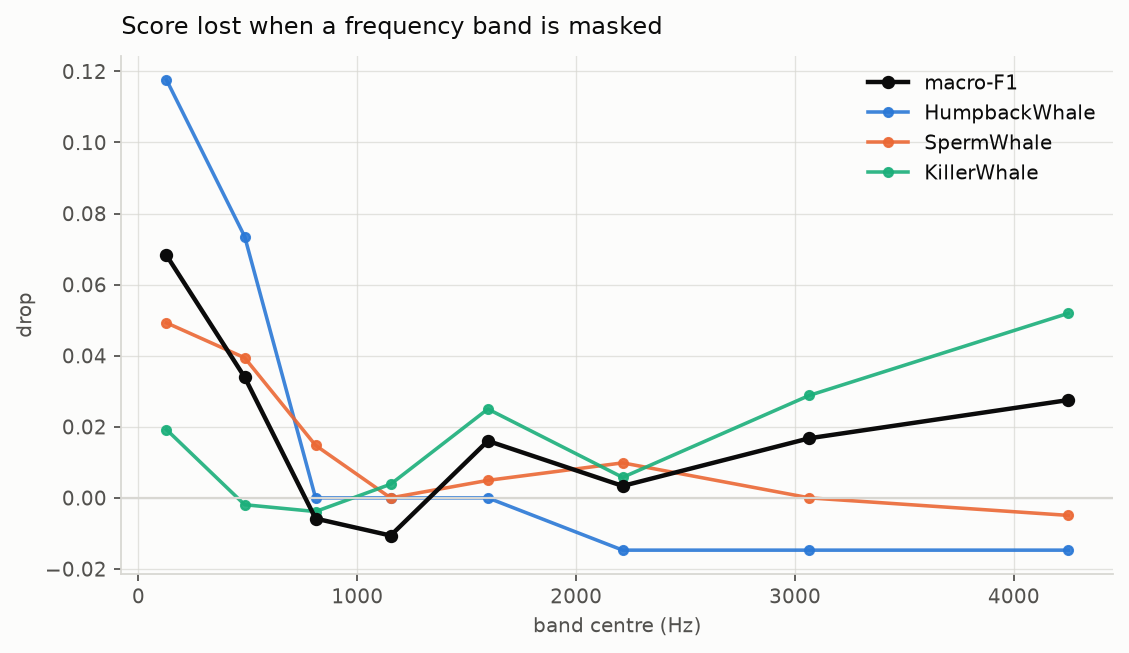

In [3]:
display(Image(filename=str(REPORT / "occlusion.png")))

## Grad-CAM

Sampled from correctly classified held-out windows, so the maps show evidence the model acted on
rather than a failure case.

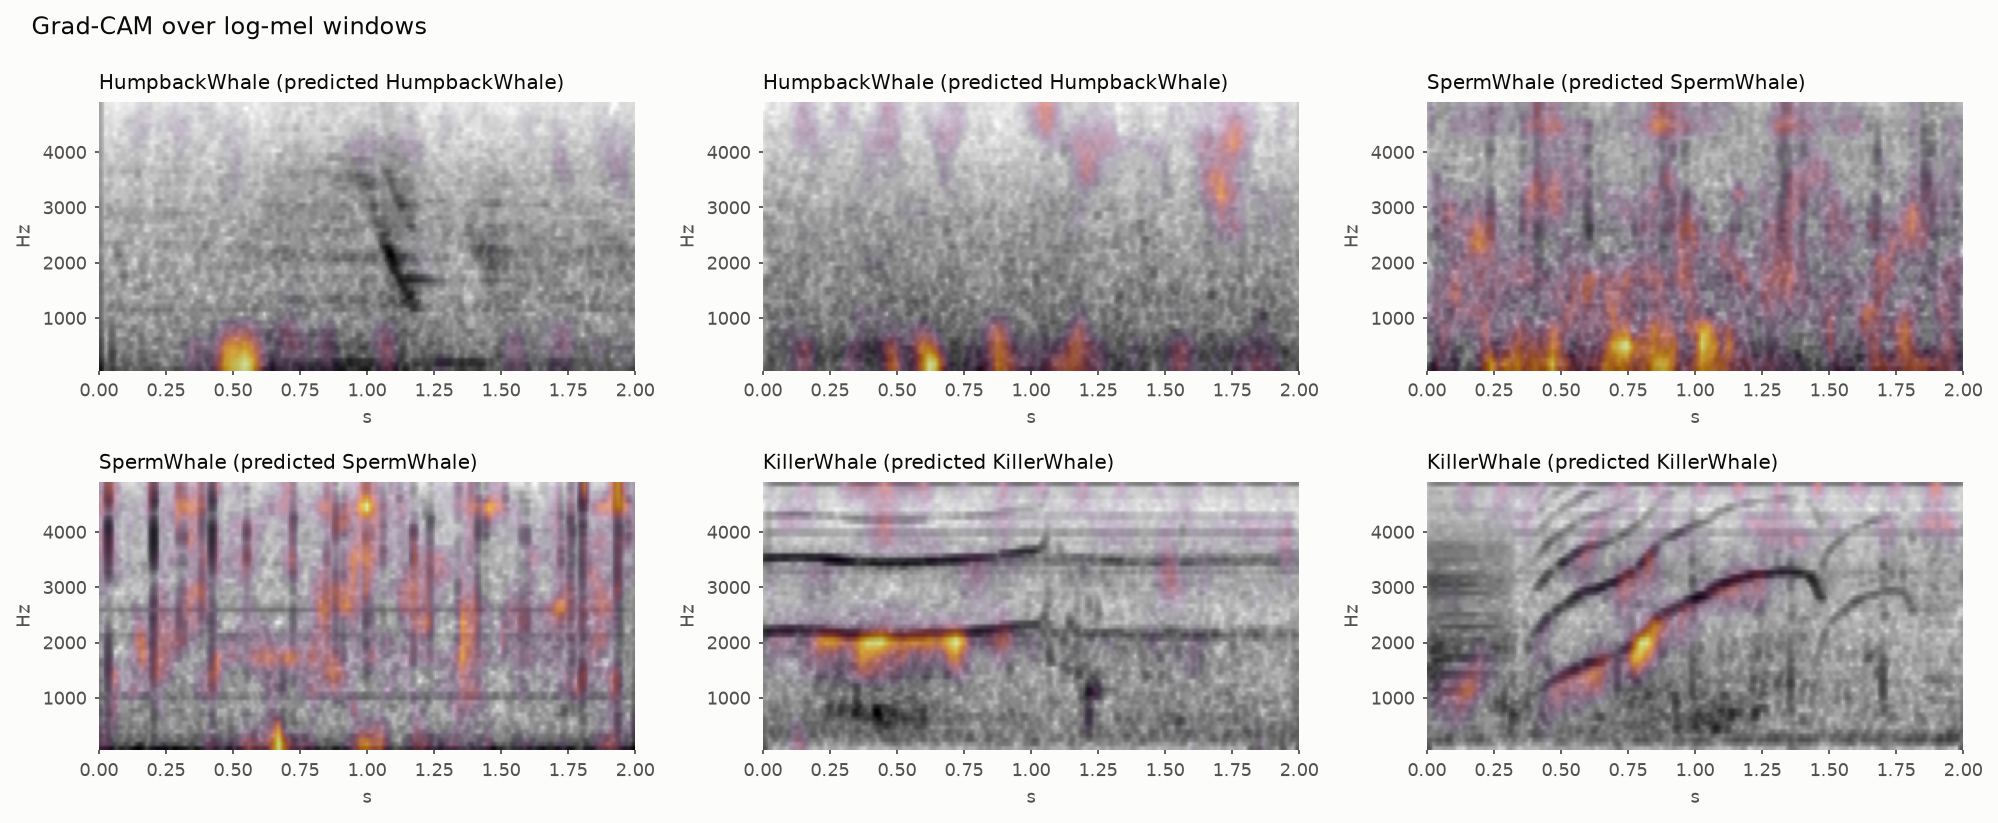

,example,peak_frequency_hz
0,HumpbackWhale (predicted HumpbackWhale),247.701327
1,HumpbackWhale (predicted HumpbackWhale),50.000000
2,SpermWhale (predicted SpermWhale),50.000000
3,SpermWhale (predicted SpermWhale),3836.549856
4,KillerWhale (predicted KillerWhale),1040.510018
5,KillerWhale (predicted KillerWhale),4704.211881


In [4]:
display(Image(filename=str(REPORT / EXPLAINED / "gradcam.png")))
pd.read_csv(REPORT / EXPLAINED / "gradcam_peaks.csv")

## Which hand-engineered features carried the tree baseline

Worth comparing against the occlusion profile. If the trees lean on descriptors covering a band the
CNN does not need, the two representations are not using the same evidence.

xgboost


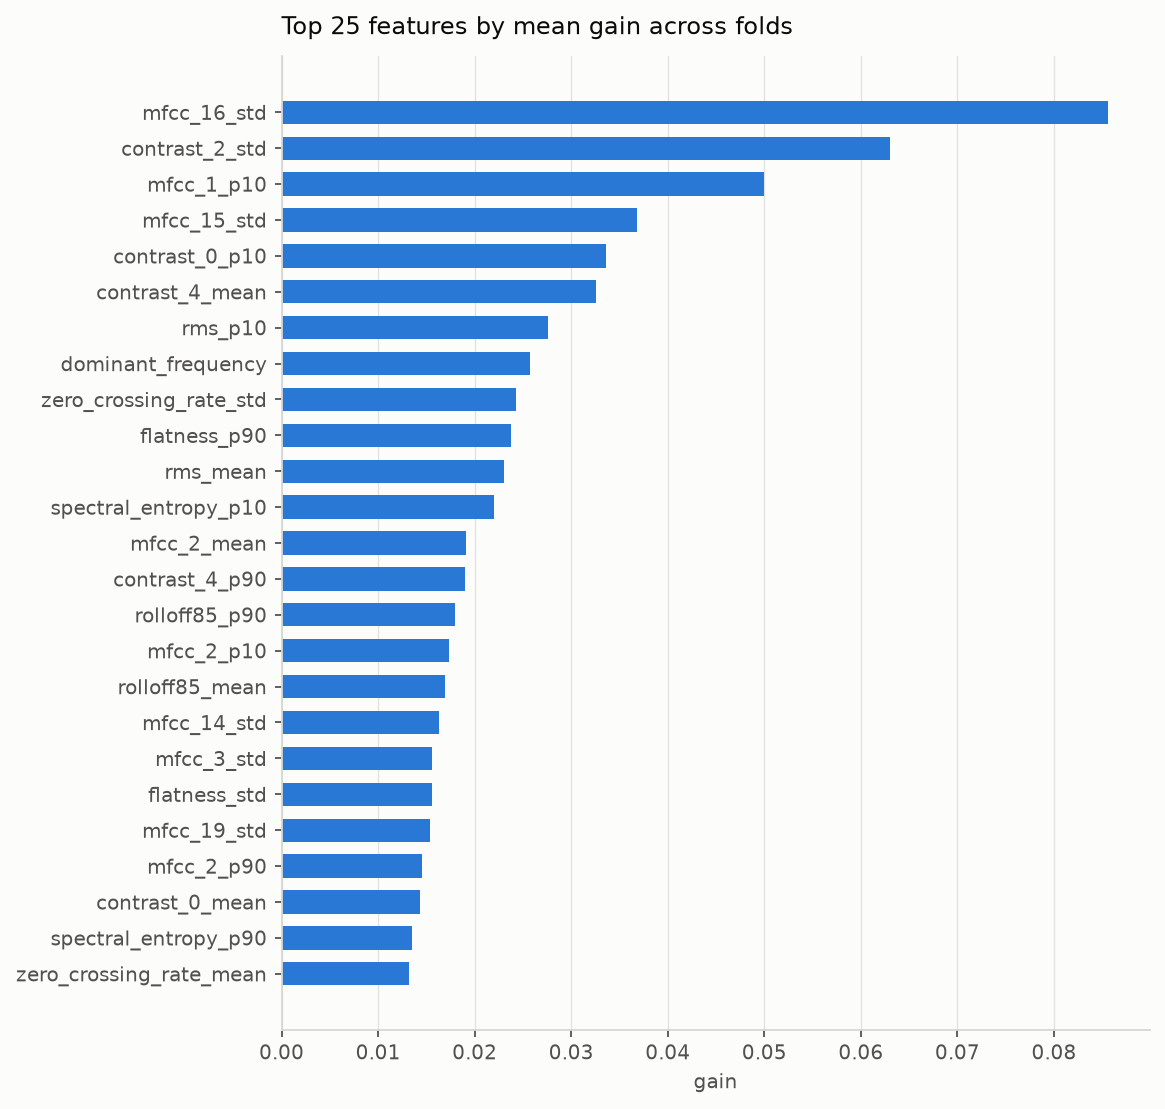

metadata


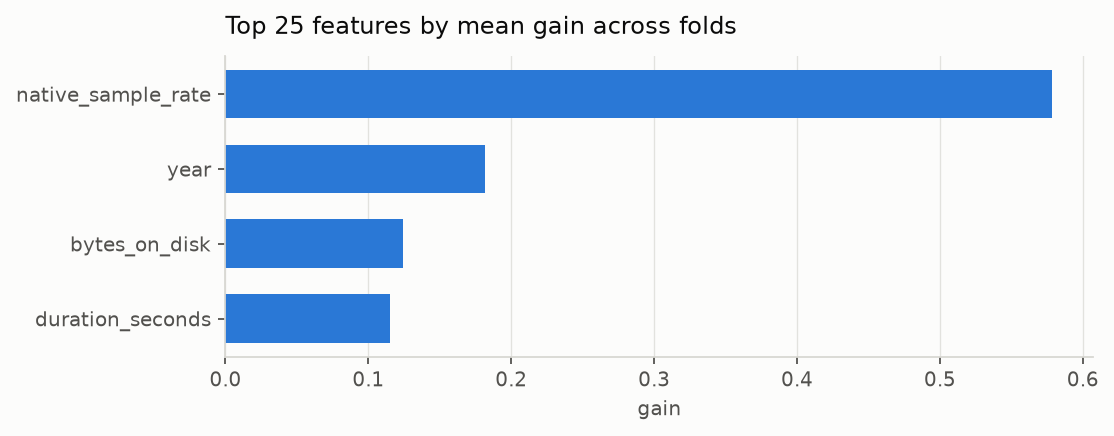

In [5]:
for model in ("xgboost", "metadata"):
    path = REPORT / f"feature_importance_{model}.png"
    if path.exists():
        print(model)
        display(Image(filename=str(path)))